In [2]:


### Global Variables
DATA_SAVE_PATH = "../../../models/used_data"
DAYS_PER_EPISODE = 3
TRAIN_TEST_SPLIT_FRACTION = 0.2  # Amount of data you reserve for testing.
BUFFER_DAYS = 3  # Amount of days that needs to be between the test episodes.

In [3]:
from Simulation.suite_simple_trading.pre_processing import clean_data
import pandas as pd
import os
from Simulation.suite_simple_trading.data_splitting import get_or_create_train_test_split

### Getting data

raw_data_path = '../../../data/2025_minute.csv'
cleaned_data_cache_path = '../../../data/2025_minute_cleaned.pkl'

if os.path.exists(cleaned_data_cache_path):
    print(f"Loading cached cleaned data from: {cleaned_data_cache_path}")
    cleaned_df = pd.read_pickle(cleaned_data_cache_path)
else:
    print("No cached data found. Running the full cleaning process...")
    raw_df = pd.read_csv(raw_data_path, sep=';')
    cleaned_df = clean_data(raw_df)
    print(f"Saving cleaned data to cache: {cleaned_data_cache_path}")
    cleaned_df.to_pickle(cleaned_data_cache_path)

all_data = cleaned_df[['Datetime', 'Imbalance Price']]
train_df, test_df, nr_of_episodes = get_or_create_train_test_split(
    all_data=all_data,
    save_path=DATA_SAVE_PATH,
    days_per_episode=DAYS_PER_EPISODE,
    test_fraction=TRAIN_TEST_SPLIT_FRACTION,
    buffer_days=BUFFER_DAYS
)

Loading cached cleaned data from: ../../../data/2025_minute_cleaned.pkl
--- Loading existing train/test data from '../../../models/used_data' ---
--- Data loaded successfully. Found 19 test episodes. ---
Test Data Size / Train Data Size: 0.25


In [57]:
from sb3_contrib.common.maskable.policies import MaskableActorCriticPolicy
from sb3_contrib import MaskablePPO
from Simulation.suite_simple_trading.observation_wrappers import RobustScalingWrapper

### The model (Environment) used in all agents
from Simulation.suite_simple_trading.model import ExtendedBatteryEnv

from Simulation.suite_simple_trading.plotting import plot_simulation_results_minute_by_minute

from Simulation.suite_simple_trading.metrics import print_agent_performance
from Simulation.suite_simple_trading.plotting import plot_total_charged_discharged_in_quarter_per_price


In [11]:


train_env = ExtendedBatteryEnv(
    battery_capacity_mwh=10.0,
    charge_discharge_rate_mw=5.0,
    all_data=train_df,
    days_per_episode=DAYS_PER_EPISODE
)
train_env_scaled_obs = RobustScalingWrapper(train_env)
ppo_agent = MaskablePPO(MaskableActorCriticPolicy, train_env_scaled_obs)
ppo_agent.learn(total_timesteps=10_000, progress_bar=True)


Output()

--- Initializing Robust Observation Scaling Wrapper (Method: robust) ---
Price (Robust): Median=78.17, IQR=87.78
--- Wrapper ready. ---


In [13]:
from Simulation.suite_simple_trading.policy import PPOAgentDecisionMaker
from Simulation.suite_simple_trading.simulation import run_evaluation

test_env = ExtendedBatteryEnv(
    battery_capacity_mwh=10.0,
    charge_discharge_rate_mw=5.0,
    all_data=test_df,
    days_per_episode=DAYS_PER_EPISODE
)
test_env_scaled = RobustScalingWrapper(test_env)
decision_maker_PPO = PPOAgentDecisionMaker(ppo_agent, test_env_scaled)

result_ppo = run_evaluation(test_env_scaled,
                            ppo_agent, number_of_episodes=nr_of_episodes)
print(f"reward ppo: {sum(result_ppo["real_rewards"])}")
result_ppo.pop("episodic_rewards")
history_df = pd.DataFrame(result_ppo)
history_df['Datetime'] = test_df['Datetime']

--- Initializing Robust Observation Scaling Wrapper (Method: robust) ---
Price (Robust): Median=78.92, IQR=91.47
--- Wrapper ready. ---
Starting episode 1/19
From 2025-01-03 00:00:00+00:00 to 2025-01-05 23:59:00+00:00
Finished with total (scaled) reward: 8666.53
Starting episode 2/19
From 2025-01-16 00:00:00+00:00 to 2025-01-18 23:59:00+00:00
Finished with total (scaled) reward: 138.37
Starting episode 3/19
From 2025-01-29 00:00:00+00:00 to 2025-01-31 23:59:00+00:00
Finished with total (scaled) reward: 2448.10
Starting episode 4/19
From 2025-02-05 00:00:00+00:00 to 2025-02-07 23:59:00+00:00
Finished with total (scaled) reward: 1316.36
Starting episode 5/19
From 2025-02-14 00:00:00+00:00 to 2025-02-16 23:59:00+00:00
Finished with total (scaled) reward: 577.33
Starting episode 6/19
From 2025-03-07 00:00:00+00:00 to 2025-03-09 23:59:00+00:00
Finished with total (scaled) reward: 8615.17
Starting episode 7/19
From 2025-03-31 00:00:00+00:00 to 2025-04-02 23:59:00+00:00
Finished with total (s

### The model to compare
Introduce a little penalty for trading, this should mitigate effects like, because now these actions give a penalty, this kind of reflects the degradation penalty of the battery.
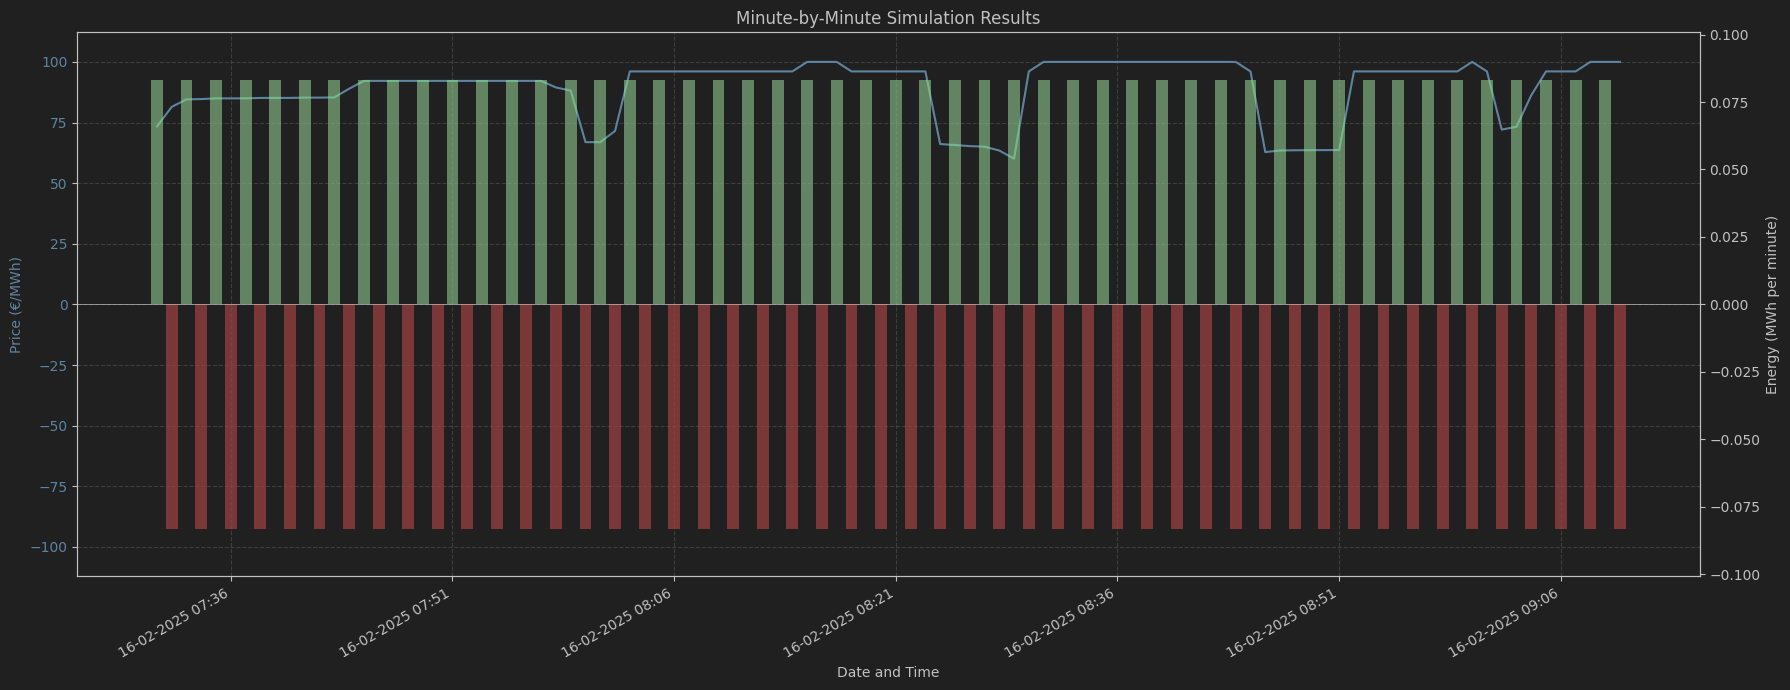

In [31]:
import gymnasium as gym

class DegradationCostWrapper(gym.Wrapper):
    def __init__(self, env, cost_per_mwh=1.0):
        super().__init__(env)
        self.cost = cost_per_mwh

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)

        # Calculate throughput (absolute energy moved)
        energy_moved = abs(info.get('energy_charged_discharged', 0))

        # Apply penalty
        penalty = energy_moved * self.cost
        new_reward = reward - penalty

        return obs, new_reward, terminated, truncated, info

In [32]:
train_env_compare = ExtendedBatteryEnv(
    battery_capacity_mwh=10.0,
    charge_discharge_rate_mw=5.0,
    all_data=train_df,
    days_per_episode=DAYS_PER_EPISODE
)
train_env_scaled_obs_compare = RobustScalingWrapper(train_env_compare)
train_env_scaled_obs_shaped_reward = DegradationCostWrapper(train_env_scaled_obs_compare, 100)
ppo_agent_compare = MaskablePPO(MaskableActorCriticPolicy, train_env_scaled_obs_shaped_reward)
ppo_agent_compare.learn(200_000)

--- Initializing Robust Observation Scaling Wrapper (Method: robust) ---
Price (Robust): Median=78.17, IQR=87.78
--- Wrapper ready. ---


KeyboardInterrupt: 

In [15]:
from Simulation.suite_simple_trading.policy import PPOAgentDecisionMaker
from Simulation.suite_simple_trading.simulation import run_evaluation
test_env_compare = ExtendedBatteryEnv(
    battery_capacity_mwh=10.0,
    charge_discharge_rate_mw=5.0,
    all_data=test_df,
    days_per_episode=DAYS_PER_EPISODE
)

test_env_scaled_compare = RobustScalingWrapper(test_env_compare)
test_env_scaled_shaped_compare = DegradationCostWrapper(test_env_scaled_compare, 100)

result_ppo_compare = run_evaluation(test_env_scaled_shaped_compare,
                            ppo_agent_compare, number_of_episodes=nr_of_episodes)
print(f"reward ppo: {sum(result_ppo_compare["real_rewards"])}")
result_ppo_compare.pop("episodic_rewards")
history_df_compare = pd.DataFrame(result_ppo_compare)
history_df_compare['Datetime'] = test_df['Datetime']

--- Initializing Robust Observation Scaling Wrapper (Method: robust) ---
Price (Robust): Median=78.92, IQR=91.47
--- Wrapper ready. ---
Starting episode 1/19
From 2025-01-03 00:00:00+00:00 to 2025-01-05 23:59:00+00:00
Finished with total (scaled) reward: 2879.55
Starting episode 2/19
From 2025-01-16 00:00:00+00:00 to 2025-01-18 23:59:00+00:00
Finished with total (scaled) reward: 0.00
Starting episode 3/19
From 2025-01-29 00:00:00+00:00 to 2025-01-31 23:59:00+00:00
Finished with total (scaled) reward: 119.40
Starting episode 4/19
From 2025-02-05 00:00:00+00:00 to 2025-02-07 23:59:00+00:00
Finished with total (scaled) reward: 101.91
Starting episode 5/19
From 2025-02-14 00:00:00+00:00 to 2025-02-16 23:59:00+00:00
Finished with total (scaled) reward: 12.63
Starting episode 6/19
From 2025-03-07 00:00:00+00:00 to 2025-03-09 23:59:00+00:00
Finished with total (scaled) reward: 3447.14
Starting episode 7/19
From 2025-03-31 00:00:00+00:00 to 2025-04-02 23:59:00+00:00
Finished with total (scaled

In [20]:
### Without action penalty

import matplotlib.pyplot as plt
plt.rcdefaults() # Resets everything to standard Matplotlib defaults



Saving plot to: plots/test_reward_shaping


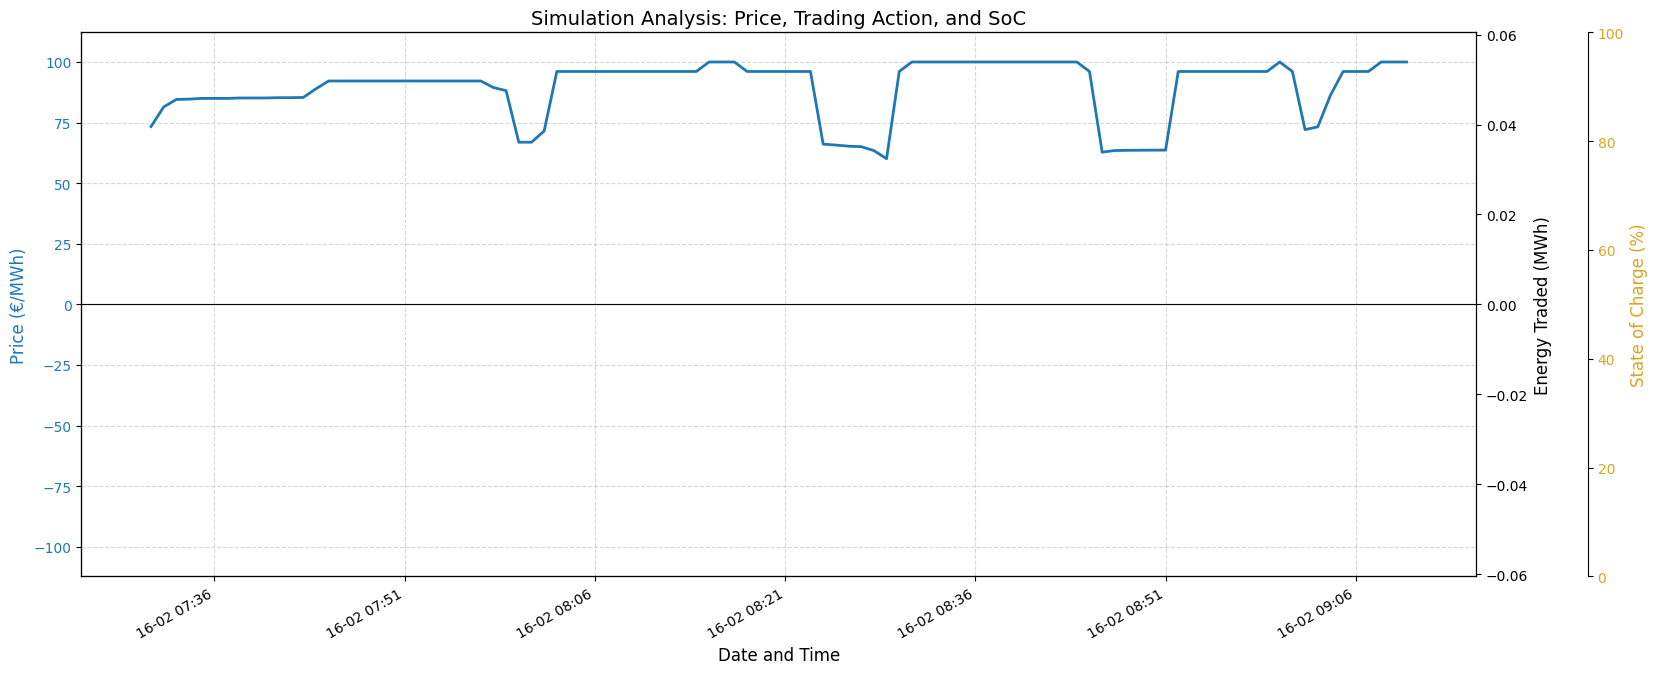

In [21]:
from Simulation.suite_simple_trading.plotting import plot_simulation_results_minute_by_minute

plot_simulation_results_minute_by_minute(
    history_df,
    "test_reward_shaping",
    20_500,
    20_600,
    10
)

### With action penalty

Saving plot to: plots/test_reward_shaping


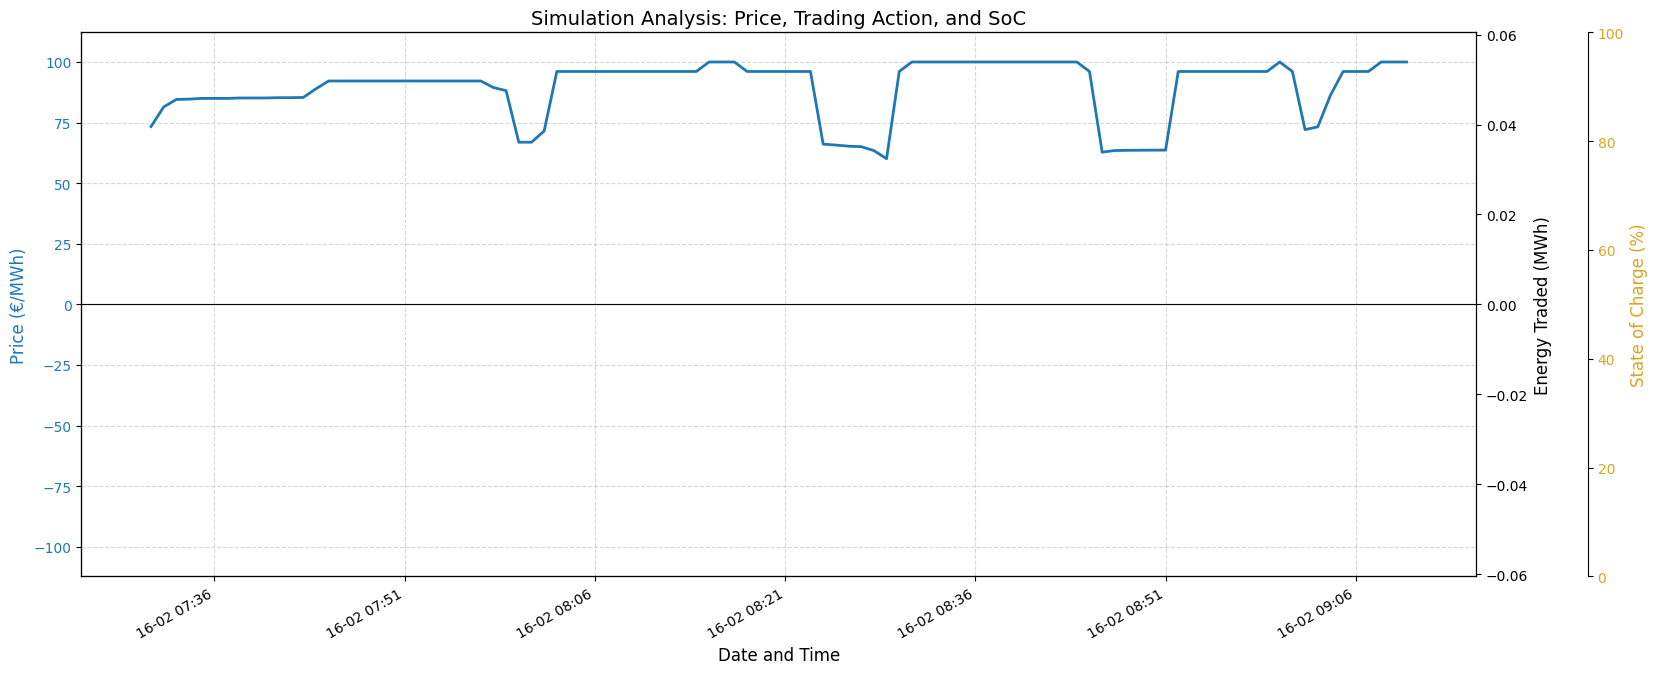

In [17]:
from Simulation.suite_simple_trading.plotting import plot_simulation_results_minute_by_minute, plot_feature_importance

plot_simulation_results_minute_by_minute(
    history_df_compare,
    "test_reward_shaping",
    20_500,
    20_600,
    10
)

Saving plot to: plots/default


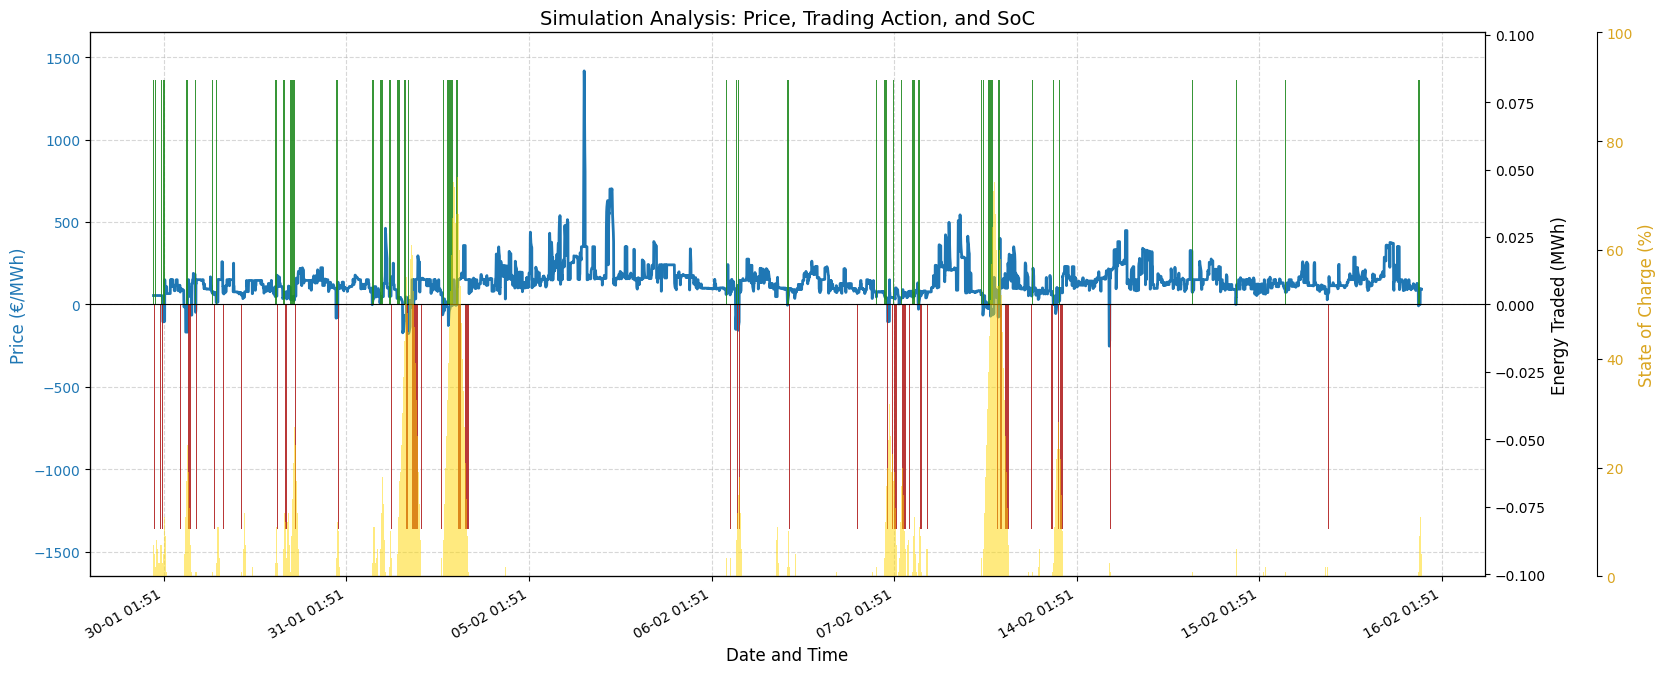

In [25]:
from Simulation.suite_simple_trading.plotting import plot_simulation_results_minute_by_minute
plot_simulation_results_minute_by_minute(
    history_df,
    "default",
    10_000,
    20_000
)

Saving plot to: plots/test_reward_shaping_action_penalty


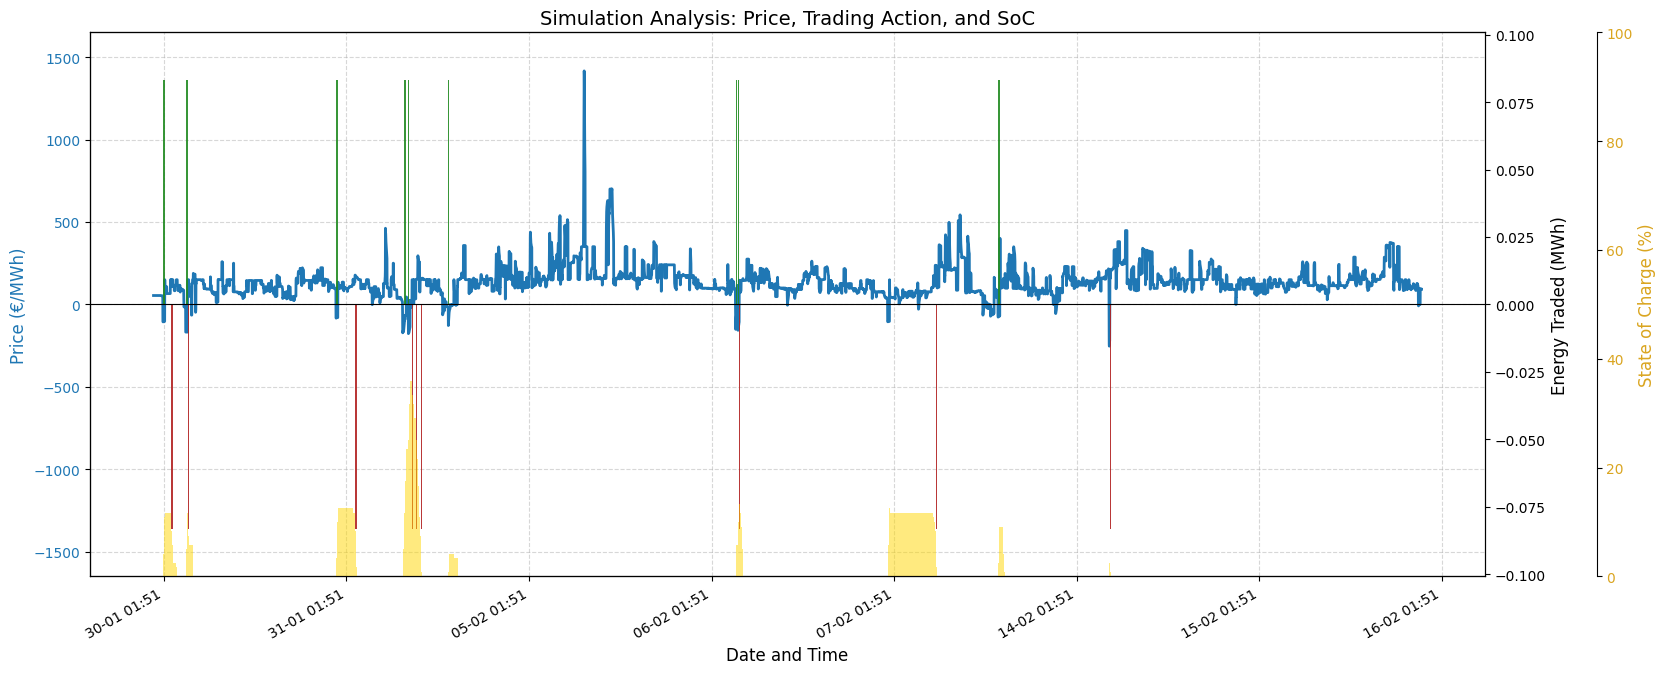

In [40]:

plot_simulation_results_minute_by_minute(
    history_df_compare,
    "test_reward_shaping_action_penalty",
    10_000,
    20_000
)

In [18]:
print_agent_performance(history_df, "PPO Agent")


  PERFORMANCE REPORT: PPO Agent
  Pos. Profit Quarters : 116
  Neg. Profit Quarters : 69
----------------------------------------
  Success Rate (Active): 62.70%
  Mean Reward / active Quarter: €57.1022
----------------------------------------
  'Trap' Quarters      : 10
  (Started good -> Ended bad)



In [19]:
print_agent_performance(history_df_compare, "PPO Agent Compare")

  PERFORMANCE REPORT: PPO Agent Compare
  Pos. Profit Quarters : 57
  Neg. Profit Quarters : 9
----------------------------------------
  Success Rate (Active): 86.36%
  Mean Reward / active Quarter: €115.8517
----------------------------------------
  'Trap' Quarters      : 4
  (Started good -> Ended bad)



Introducing penalty for (dis)charging makes the agent more risk averse

### Testing a SoC wrapper
this wrapper will give a penalty to a low SoC, this to encourage leveraging, and still buying on positive prices

In [25]:
from Simulation.suite_simple_trading.observation_wrappers import RobustScalingWrapper, FlexibleSoCPenaltyWrapper

train_env_soc_penalty = ExtendedBatteryEnv(
    battery_capacity_mwh=10.0,
    charge_discharge_rate_mw=5.0,
    all_data=train_df,
    days_per_episode=DAYS_PER_EPISODE
)
train_env_final = RobustScalingWrapper(train_env_soc_penalty)
train_env_shaped = FlexibleSoCPenaltyWrapper(
    train_env_final,
    weight=10.0,
    mode='quadratic'
)
# 4. Train the Agent
ppo_agent_soc_penalty = MaskablePPO(MaskableActorCriticPolicy, train_env_shaped)
ppo_agent_soc_penalty.learn(total_timesteps=500_000)

--- Initializing Robust Observation Scaling Wrapper (Method: robust) ---
Price (Robust): Median=78.17, IQR=87.78
--- Wrapper ready. ---


In [26]:
from Simulation.suite_simple_trading.simulation import run_evaluation

# 1. Create Evaluation Environment
test_env_soc_penalty = ExtendedBatteryEnv(
    battery_capacity_mwh=10.0,
    charge_discharge_rate_mw=5.0,
    all_data=test_df,
    days_per_episode=DAYS_PER_EPISODE
)

test_env_final = RobustScalingWrapper(test_env_soc_penalty)
test_env_shaped_final = FlexibleSoCPenaltyWrapper(
    test_env_final,
    weight=10.0,
    mode='quadratic'
)

result_soc_penalty = run_evaluation(
    test_env_shaped_final,
    ppo_agent_soc_penalty,
    number_of_episodes=nr_of_episodes
)

print(f"Total Real Reward (PPO with SoC Penalty): {sum(result_soc_penalty['real_rewards']):.2f}")
result_soc_penalty.pop("episodic_rewards")
history_df_soc_penalty = pd.DataFrame(result_soc_penalty)
history_df_soc_penalty['Datetime'] = test_df['Datetime'].reset_index(drop=True)

--- Initializing Robust Observation Scaling Wrapper (Method: robust) ---
Price (Robust): Median=78.92, IQR=91.47
--- Wrapper ready. ---
Starting episode 1/19
From 2025-01-03 00:00:00+00:00 to 2025-01-05 23:59:00+00:00
Finished with total (scaled) reward: -1824.12
Starting episode 2/19
From 2025-01-16 00:00:00+00:00 to 2025-01-18 23:59:00+00:00
Finished with total (scaled) reward: -16091.42
Starting episode 3/19
From 2025-01-29 00:00:00+00:00 to 2025-01-31 23:59:00+00:00
Finished with total (scaled) reward: -2321.05
Starting episode 4/19
From 2025-02-05 00:00:00+00:00 to 2025-02-07 23:59:00+00:00
Finished with total (scaled) reward: -14486.66
Starting episode 5/19
From 2025-02-14 00:00:00+00:00 to 2025-02-16 23:59:00+00:00
Finished with total (scaled) reward: -17092.54
Starting episode 6/19
From 2025-03-07 00:00:00+00:00 to 2025-03-09 23:59:00+00:00
Finished with total (scaled) reward: 2333.74
Starting episode 7/19
From 2025-03-31 00:00:00+00:00 to 2025-04-02 23:59:00+00:00
Finished wit

Saving plot to: plots/test_reward_shaping_soc_penalty


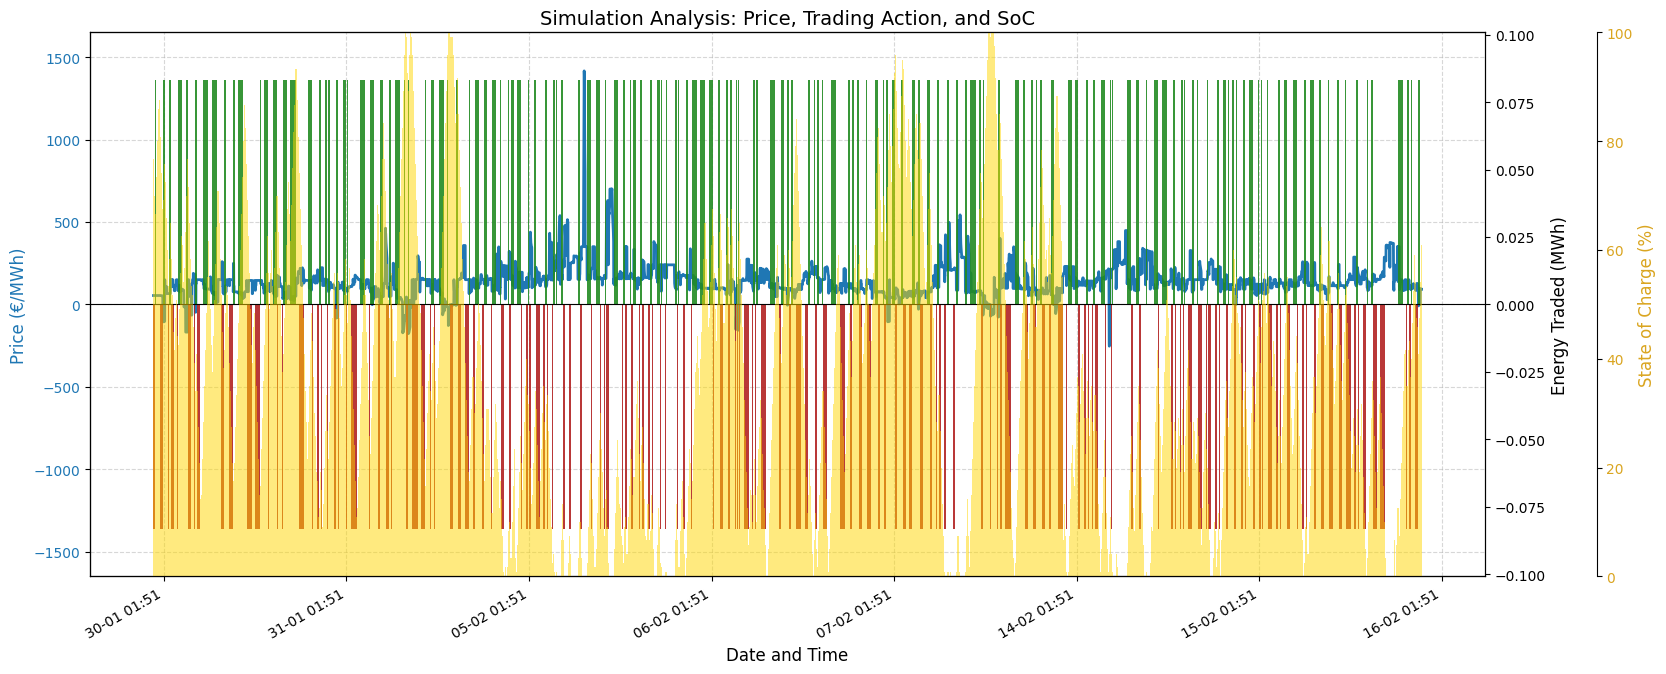

In [28]:
from Simulation.suite_simple_trading.plotting import plot_simulation_results_minute_by_minute
plot_simulation_results_minute_by_minute(
    history_df_soc_penalty,
    "test_reward_shaping_soc_penalty",
    10_000,
    20_000
)

In [29]:
print_agent_performance(history_df_soc_penalty, "PPO SoC penalty")


  PERFORMANCE REPORT: PPO SoC penalty
  Pos. Profit Quarters : 224
  Neg. Profit Quarters : 181
----------------------------------------
  Success Rate (Active): 55.31%
  Mean Reward / active Quarter: €47.2585
----------------------------------------
  'Trap' Quarters      : 11
  (Started good -> Ended bad)



### Combining both penalty wrappers

In [38]:
train_env_soc_and_idle_penalty = ExtendedBatteryEnv(
    battery_capacity_mwh=10.0,
    charge_discharge_rate_mw=5.0,
    all_data=train_df,
    days_per_episode=DAYS_PER_EPISODE
)
train_env_soc_idle_penalty = RobustScalingWrapper(train_env_soc_and_idle_penalty)
train_env_soc_wrapped = FlexibleSoCPenaltyWrapper(
    train_env_soc_idle_penalty,
    weight=10.0,
    mode='linear'
)
test_env_soc_idle_penal_wrapped = DegradationCostWrapper(train_env_soc_wrapped, 25)

# 4. Train the Agent
ppo_agent_soc_penalty_idle_penalty = MaskablePPO(MaskableActorCriticPolicy, test_env_soc_idle_penal_wrapped)
ppo_agent_soc_penalty_idle_penalty.learn(total_timesteps=1_000_000)



--- Initializing Robust Observation Scaling Wrapper (Method: robust) ---
Price (Robust): Median=78.17, IQR=87.78
--- Wrapper ready. ---


In [39]:
from Simulation.suite_simple_trading.simulation import run_evaluation

# 1. Create Evaluation Environment
test_env = ExtendedBatteryEnv(
    battery_capacity_mwh=10.0,
    charge_discharge_rate_mw=5.0,
    all_data=test_df,
    days_per_episode=DAYS_PER_EPISODE
)

test_env_scaled = RobustScalingWrapper(test_env_soc_penalty)
test_env_scaled_SoC_penal = FlexibleSoCPenaltyWrapper(
    test_env_scaled,
    weight=10.0,
    mode='linear'
)
test_env_scaled_SoC_idle_penal = DegradationCostWrapper(test_env_scaled_SoC_penal, 100)


result_soc_idle_penalty = run_evaluation(
    test_env_scaled_SoC_idle_penal,
    ppo_agent_soc_penalty_idle_penalty,
    number_of_episodes=nr_of_episodes
)

print(f"Total Real Reward (PPO with SoC Penalty): {sum(result_soc_idle_penalty['real_rewards']):.2f}")
result_soc_idle_penalty.pop("episodic_rewards")
history_df_soc_idle_penalty = pd.DataFrame(result_soc_idle_penalty)
history_df_soc_idle_penalty['Datetime'] = test_df['Datetime'].reset_index(drop=True)

--- Initializing Robust Observation Scaling Wrapper (Method: robust) ---
Price (Robust): Median=78.92, IQR=91.47
--- Wrapper ready. ---
Starting episode 1/19
From 2025-01-03 00:00:00+00:00 to 2025-01-05 23:59:00+00:00
Finished with total (scaled) reward: -22270.32
Starting episode 2/19
From 2025-01-16 00:00:00+00:00 to 2025-01-18 23:59:00+00:00
Finished with total (scaled) reward: -41032.73
Starting episode 3/19
From 2025-01-29 00:00:00+00:00 to 2025-01-31 23:59:00+00:00
Finished with total (scaled) reward: -28890.61
Starting episode 4/19
From 2025-02-05 00:00:00+00:00 to 2025-02-07 23:59:00+00:00
Finished with total (scaled) reward: -37533.85
Starting episode 5/19
From 2025-02-14 00:00:00+00:00 to 2025-02-16 23:59:00+00:00
Finished with total (scaled) reward: -39267.79
Starting episode 6/19
From 2025-03-07 00:00:00+00:00 to 2025-03-09 23:59:00+00:00
Finished with total (scaled) reward: -10831.93
Starting episode 7/19
From 2025-03-31 00:00:00+00:00 to 2025-04-02 23:59:00+00:00
Finished

Saving plot to: plots/test_reward_shaping_soc_penalty


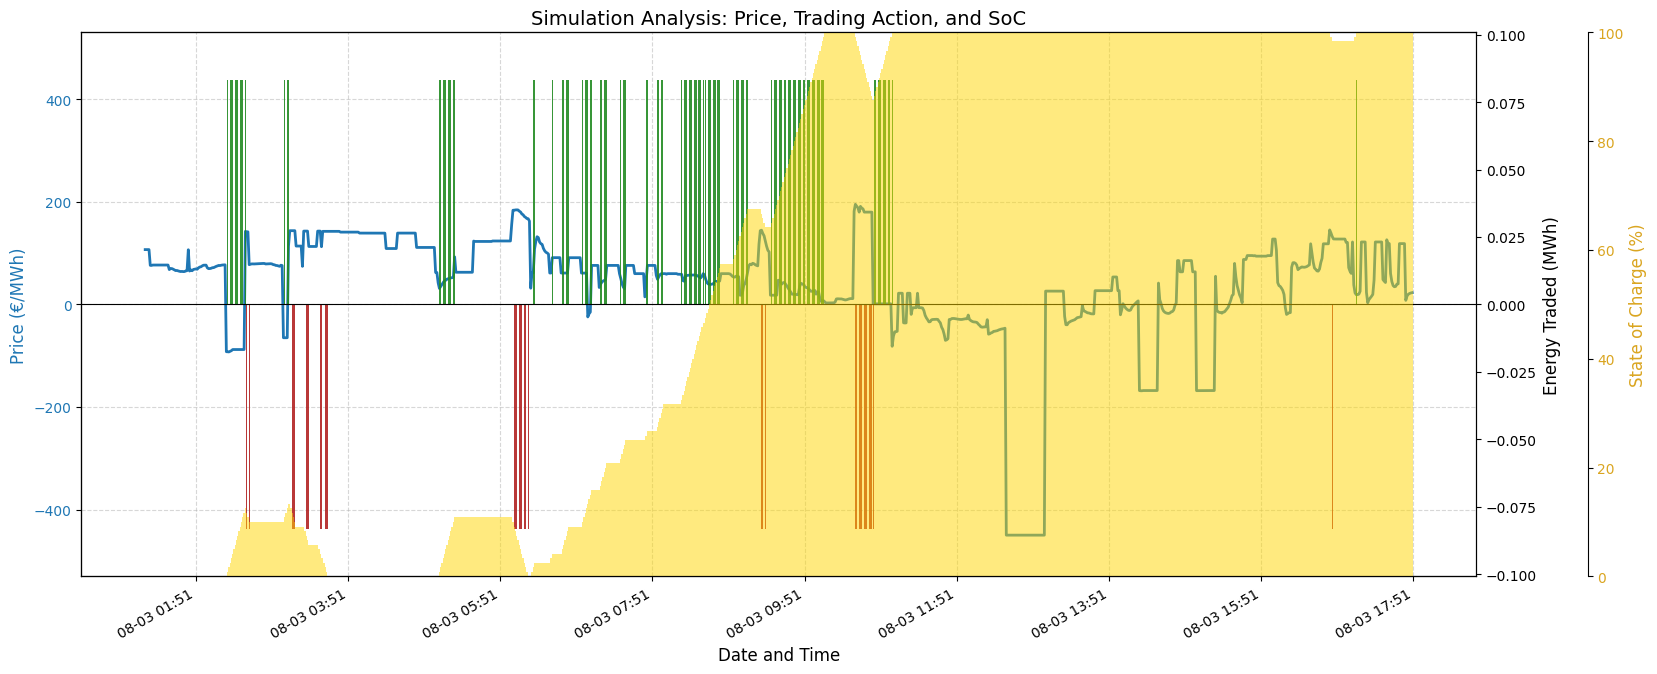

In [56]:
from Simulation.suite_simple_trading.plotting import plot_simulation_results_minute_by_minute
plot_simulation_results_minute_by_minute(
    history_df_soc_idle_penalty,
    "test_reward_shaping_soc_penalty",
    23_000,
    24_000
)

In [44]:
print_agent_performance(history_df_soc_idle_penalty, "PPO SoC penalty")


  PERFORMANCE REPORT: PPO SoC penalty
  Pos. Profit Quarters : 113
  Neg. Profit Quarters : 66
----------------------------------------
  Success Rate (Active): 63.13%
  Mean Reward / active Quarter: €73.7395
----------------------------------------
  'Trap' Quarters      : 8
  (Started good -> Ended bad)



/home/lander/Documents/school/Thesis/ThesisGit/Simulation/suite_simple_trading/plotting.py:268: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  charge_means = charge_quarters.groupby('price_bin')['total_charged_per_quarter'].mean()
/home/lander/Documents/school/Thesis/ThesisGit/Simulation/suite_simple_trading/plotting.py:269: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  discharge_means = discharge_quarters.groupby('price_bin')['total_discharged_per_quarter'].mean()


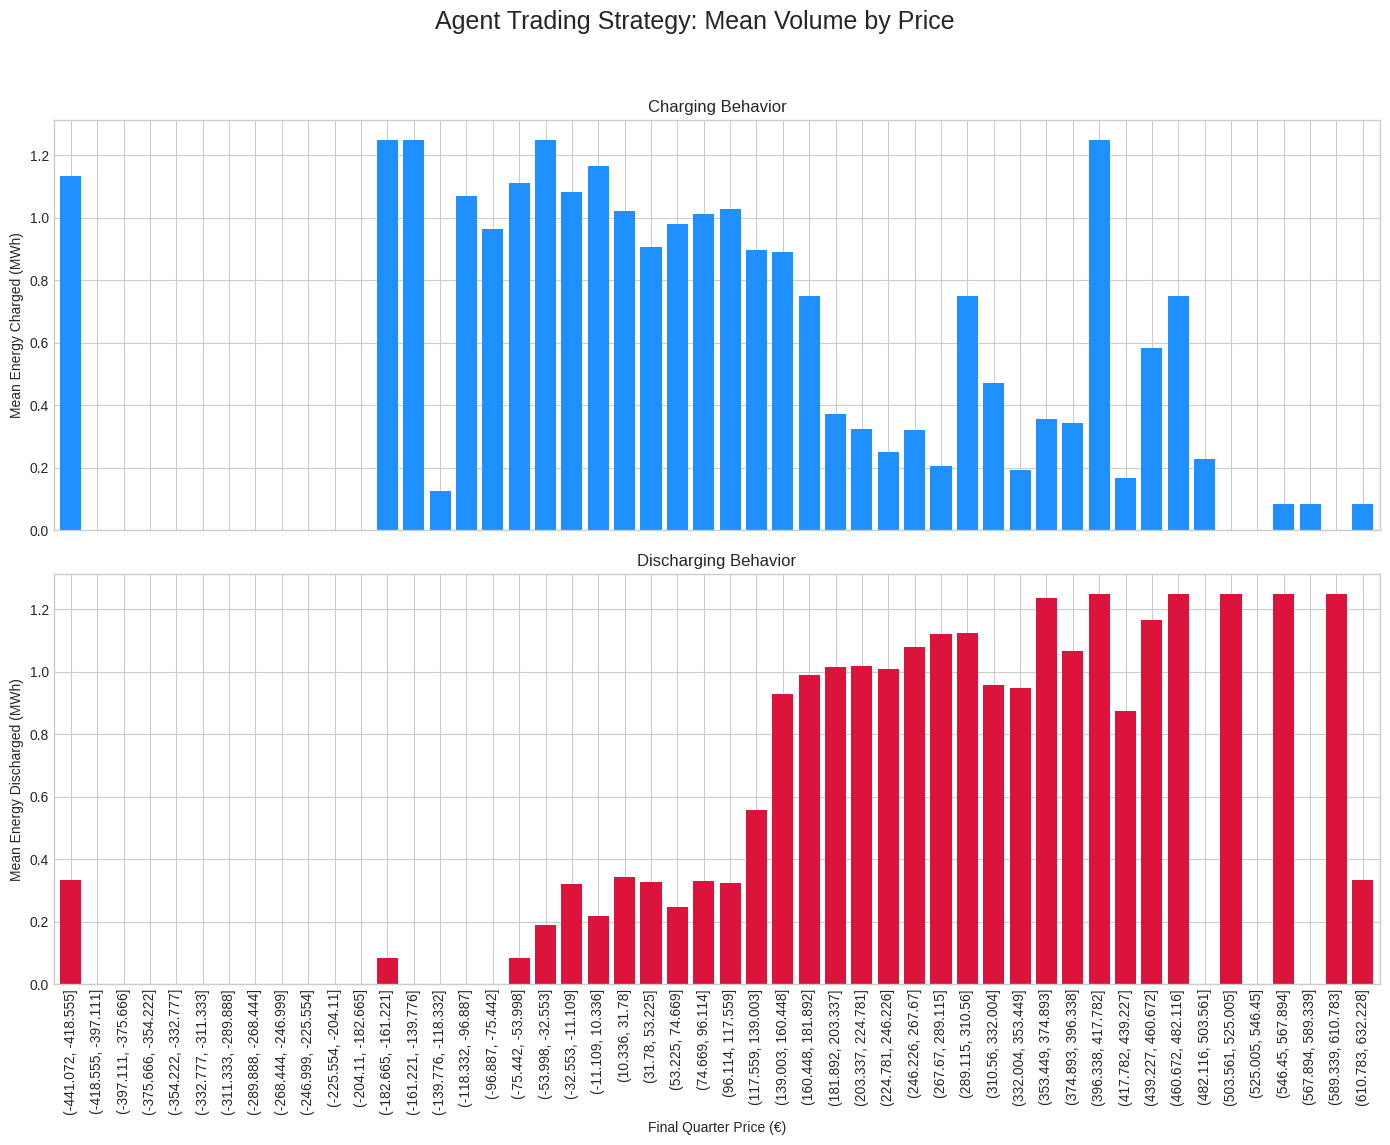

In [58]:
plot_total_charged_discharged_in_quarter_per_price(history_df_soc_idle_penalty)